# Medical Insurance Cost Prediction using Linear Regression

This project explores a medical insurance dataset and uses Linear Regression to predict insurance charges based on various factors such as age, BMI, and smoking status.

## Task 1: Import Required Libraries

In this step, we import libraries for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## Task 2: Load and Explore the Dataset

The dataset contains information about individuals and their medical insurance costs.

Each row represents a person, and the columns describe their characteristics such as age, BMI, and smoking status.

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Preview of the Dataset

The first five rows of the dataset are displayed using the df.head() function.

Each row represents an individual and their insurance information.

The dataset includes the following columns:
- age: Age of the individual
- sex: Gender of the individual
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status (yes/no)
- region: Residential region
- charges: Medical insurance cost

This preview helps us understand the structure of the dataset and the type of data stored in each column.

### Dataset Structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Dataset Structure

The dataset contains 1338 entries and 7 columns.

There are no missing values, as all columns have 1338 non-null values.

The dataset includes different data types:
- Integer (int64): age, children
- Float (float64): bmi, charges
- Categorical (object): sex, smoker, region

This shows that the dataset is clean and does not require handling of missing values before analysis.

### Summary Statistics

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Summary Statistics Interpretation

From the summary statistics:

- The average age of individuals is approximately 39 years, with ages ranging from 18 to 64.
- The average BMI is around 30.66, which indicates that many individuals are in the overweight range.
- The average number of children is about 1, with a maximum of 5 dependents.
- The average insurance charge is approximately 13,270.

The charges vary significantly, with a minimum of about 1,121 and a maximum of 63,770. This indicates a wide spread in insurance costs and suggests the presence of high-cost outliers.

The standard deviation for charges is also high, showing that the data is widely dispersed.

### Checking Missing Values

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values in the dataset.

The dataset contains 1338 records.

Categorical variables: sex, smoker, region  
Numerical variables: age, bmi, children, charges

## Task 3: Exploratory Data Analysis (EDA)

In this section, we visualize the data to understand patterns and relationships between variables.

## 1. Distribution of Insurance Charges

C:\Users\Nkululeko\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


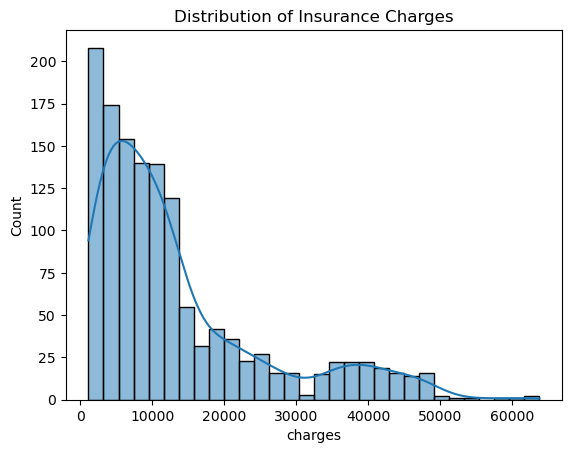

In [6]:
plt.figure()
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

## 2. Charges vs Smoking Status

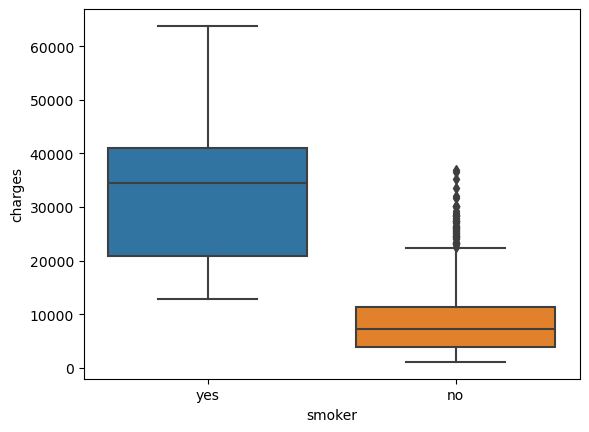

In [7]:
plt.figure()
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

## 3. Charges vs Age

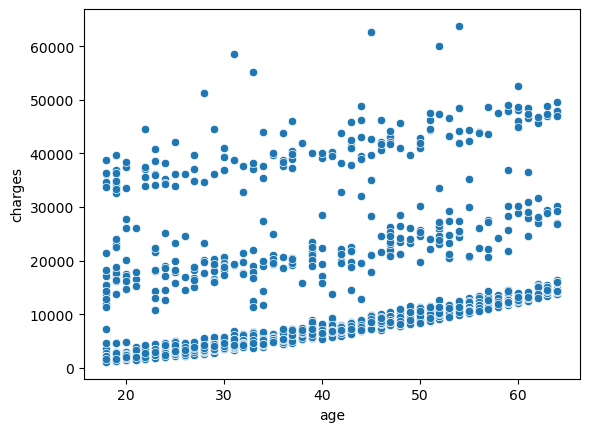

In [8]:
plt.figure()
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

### From the visualizations:

- Insurance charges are not evenly distributed.
- Smokers have much higher charges than non-smokers.
- Charges increase as age increases.
- BMI also has some effect on charges.

Smoking is the most important factor affecting insurance costs.

## Task 4: Data Preprocessing

In this step, categorical variables were converted into numerical format using dummy variables.

The original categorical columns such as sex, smoker, and region were transformed into binary columns (0 and 1).

For example:
- sex_male indicates whether the individual is male
- smoker_yes indicates whether the individual is a smoker
- region variables represent different geographic locations

The parameter drop_first=True was used to avoid multicollinearity by removing one category from each variable.

This step is important because machine learning models require numerical input to perform calculations.t.

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Task 5: Define Features and Target Variable

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

In this step, we define the features (X) and the target variable (y).

The features include all columns except 'charges', while the target variable is 'charges', which represents the medical insurance cost we want to predict.

## Task 6: Split Dataset into Training and Testing Sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is split into training and testing sets.

80% of the data is used to train the model, and 20% is used to test its performance.

The random_state ensures that the results are reproducible.

## Task 7: Train Linear Regression Model

In this step, a Linear Regression model is created and trained using the training dataset.

The model learns the relationship between the input features (X_train) and the target variable (y_train).

Once trained, the model can be used to make predictions on new, unseen data.

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
model.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

## Task 8: Make Predictions

In this step, the trained Linear Regression model is used to make predictions on the test dataset.

The model generates predicted insurance charges based on the input features.

The first five predicted values are displayed above, showing the estimated charges for the test data.

These predictions will be compared with the actual values to evaluate the model's performance.

In [14]:
predictions = model.predict(X_test)

In [15]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

comparison.head()

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457


The table above compares the actual insurance charges with the predicted values.

This helps to visually assess how close the model's predictions are to the true values.

## Task 9: Evaluate Model Performance

In [16]:
print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("MSE:", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 4181.19447375365
MSE: 33596915.851361446
RMSE: 5796.284659276272


MAE shows the average prediction error.  
MSE penalizes larger errors.  
RMSE is easier to interpret because it is in the same unit as charges.

## Task 10: Reflection

### 1. Which variables most strongly influence medical insurance charges?
Smoking status has the strongest influence on medical insurance charges, as smokers tend to have significantly higher costs. Age and BMI also play an important role, as older individuals and those with higher BMI generally have higher insurance expenses.

### 2. Why might smoking affect insurance costs?
Smoking increases the risk of serious health conditions such as heart disease, lung disease, and cancer. As a result, smokers are more likely to require medical care, which increases insurance costs.

### 3. What improvements could be made to the model?
- Use more advanced models such as Random Forest or Decision Trees for better accuracy
- Perform feature scaling to improve model performance
- Handle outliers to reduce the impact of extreme values
- Add more features or data to improve prediction accuracydd more data

## Conclusion

In this project, a Linear Regression model was developed to predict medical insurance charges based on various factors such as age, BMI, smoking status, and number of dependents.

Exploratory Data Analysis revealed that smoking status has the strongest impact on insurance charges, followed by age and BMI. The data also showed a right-skewed distribution with the presence of outliers.

After preprocessing the data and training the model, predictions were made and evaluated using MAE, MSE, and RMSE. The results showed that the model provides reasonable predictions, although there is still some level of error.

Overall, the model successfully captures general trends in the data. However, improvements can be made by using more advanced machine learning models, handling outliers, and adding more features.

This project demonstrates how data analysis and machine learning can be used to solve real-world problems such as predicting healthcare costs.